In [80]:
import os
os.chdir('/Users/ngdnhtien/Codespace/PulsatingPulseShop_pending/')

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

%config InlineBackend.figure_formats = ['svg']

In [81]:
import qiskit
from qiskit_ibm_runtime import QiskitRuntimeService
import utility as ut
import qutip as qt 
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import json
import datetime
from qiskit_ibm_runtime import SamplerV2 as Sampler
from scipy.stats import norm
from scipy.stats import gaussian_kde

In [82]:
plt.rcParams['axes.linewidth'] = 1.0
%config InlineBackend.figure_formats = ['svg']
today = datetime.datetime.now()

print(today)

2025-01-28 11:42:21.249187


# Observation of Ramsey fringes

To determine the $T_2$ time, we perform a Ramsey experiment. The full analysis on a multilevel system can be found in `Coherence and Decay of Higher Energy Levels of a Superconducting Transmon Qubit`.

Note that the exponential decay envelope of the population might not be pure exponential. More generally, it could be casted into the form of

\begin{align}
e^{-(\frac{t}{T_2^*})^\alpha}
\end{align}

## The experiment

In [165]:
service = QiskitRuntimeService()
print(service.backends())
backend = service.backend('ibm_brisbane')

qubit = 109
clbit = 0

num_qubits = int(qubit+1)
num_clbits = 1

weight = 1

rough_01_freq = backend.defaults().qubit_freq_est[qubit]
qubit_anharmonicty = backend.properties().qubits[qubit][3].value * 1e9
rough_12_freq = rough_01_freq + qubit_anharmonicty

print('Chosen backend', backend)
print(r"f01 = "+f'{round(rough_01_freq/1e9, 4)}'+' GHz')
print(r'f12 = '+f'{round(rough_12_freq/1e9, 4)}'+' GHz')
print(r'anharmonicity = '+f'{round(qubit_anharmonicty/1e9, 4)}'+' GHz')

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_sherbrooke')>, <IBMBackend('ibm_kyiv')>]
Chosen backend <IBMBackend('ibm_brisbane')>
f01 = 4.985 GHz
f12 = 4.6779 GHz
anharmonicity = -0.3071 GHz


As usual, we have a reset gate

In [166]:
dur_reset = 40
amp_reset = 0.48384
reset_gate = qiskit.circuit.Gate('reset', 1, [])

with qiskit.pulse.build(backend=backend) as reset_sched:
        drive_chan = qiskit.pulse.drive_channel(qubit)
        qiskit.pulse.set_frequency(rough_12_freq, drive_chan)
        qiskit.pulse.play(qiskit.pulse.Gaussian(duration=dur_reset, amp=amp_reset, sigma=int(dur_reset/4)), drive_chan)

Because the experiment involves manipulation of different timescales, here we define the standard units of time on IBM hardware, `dt`

In [167]:
backend_config = backend.configuration()
dt = backend_config.dt

dt

5e-10

We load up the rough-calibrated $\pi/2$ pulse parameters

In [168]:
with open("./sx12_params.json", "r") as json_file:
    sx12_params = json.load(json_file)

sx12_params

{'freq': 4677855926.141399, 'dur': 40, 'amp': 0.23636363636363633, 'beta': 0}

### Helper functions

In [171]:
with qiskit.pulse.build(backend) as x90_pulse:
    drive_chan = qiskit.pulse.drive_channel(qubit)
    qiskit.pulse.play(qiskit.pulse.Gaussian(duration=sx12_params['dur'],
                              amp=sx12_params['amp'],
                              sigma=int(sx12_params['dur']/4)), drive_chan)

We now initiate the experiment parameters. The relevant parameters are the detunings $\delta f$ in units of MHz; the delay range during which we let the system freely evolve. And then there are parameters that specify the number of shots, `num_shots`; and the number of `data_points`. 

In [172]:
detuning_MHz = float(input('Specify detuning:'))
start_delay = float(input('Start of delay:'))
end_delay = float(input('End of delay:'))
ramsey_shots = int(input('Number of shots per DP:'))

The delay range is constrained by the resolution of the AWG. 

In [173]:
granularity = backend.configuration().timing_constraints['granularity']

granularity

8

In [174]:
delay_time_dt = np.arange(start_delay, end_delay+granularity, granularity)

print(f"We're sweeping from {min(delay_time_dt)} to {max(delay_time_dt)} with {len(delay_time_dt)} data points")

We're sweeping from 8.0 to 800.0 with 100 data points


The detuned value $\delta_f$ is now converted to MHz and add to the rough estimate of the $\omega_{12}$ frequency

In [175]:
ramsey_frequency = round(rough_12_freq + detuning_MHz * 1e6, 6)

print(ramsey_frequency)

4678357270.602841


And now we initiate the circuit that implements a Ramsey experiment

In [176]:
delay = qiskit.circuit.Parameter('delay')

with qiskit.pulse.build(backend=backend) as ramsey_schedule:
    drive_chan = qiskit.pulse.drive_channel(qubit)
    qiskit.pulse.set_frequency(ramsey_frequency, drive_chan)
    qiskit.pulse.call(x90_pulse)
    qiskit.pulse.delay(delay, drive_chan)
    qiskit.pulse.call(x90_pulse)

ramsey_gate = qiskit.circuit.Gate("ramsey", 1, [delay])

qc_ramsey = qiskit.circuit.QuantumCircuit(num_qubits, num_clbits)
qc_ramsey.x(qubit)
qc_ramsey.append(ramsey_gate, [qubit])
qc_ramsey.x(qubit)
qc_ramsey.measure(qubit, clbit)
qc_ramsey.append(reset_gate, [qubit])
qc_ramsey.add_calibration(reset_gate, [qubit], reset_sched)
qc_ramsey.add_calibration(ramsey_gate, [qubit], ramsey_schedule, [delay])

exp_ramsey_circs = [qc_ramsey.assign_parameters({delay: d}, inplace=False) for d in delay_time_dt]

### Sampler & job

In [177]:
sampler = Sampler(backend)
 
sampler.options.default_shots = ramsey_shots
sampler.options.execution.meas_type = "kerneled"
sampler.options.execution.rep_delay = 0.0005

In [178]:
ramsey_job = sampler.run(exp_ramsey_circs)
print(ramsey_job.job_id())

cycfp9h01rbg008jyq00


In [180]:
print(ramsey_job.status())

QUEUED


### Saving kerneled data

In [147]:
ramsey_job_params = {'backend': backend, 'qubit': qubit, 'job_id_string': ramsey_job.job_id(), 'datetime': datetime.datetime.now(), \
                   'duration': sx12_params['dur'], 'amp': sx12_params['amp'], 'detuning_MHz': detuning_MHz, \
                   'start_delay': start_delay, 'end_delay': end_delay, 'granularity': granularity, 'ramsey_shots': ramsey_shots, \
                   'delay_overlap': False, 'mapping_01': True, 'rep_delay': sampler.options.execution.rep_delay, 'extended_delay': 0, 'idling_circuits': False, 'unconditional_reset12': True} 

path = "./characterization/ramsey/data/" 
folder_name = ramsey_job_params['job_id_string']
full_path = os.path.join(path, folder_name)

os.mkdir(full_path)

with open(f"./{path}/{ramsey_job_params['job_id_string']}/params.pkl", "wb") as f:
    pickle.dump(ramsey_job_params, f)

In [148]:
job_id_collect = 'cycdm20cw2k0008kky2g'

ramsey_job = service.job(job_id_collect)
ramsey_exp = ut.DataAnalysis(experiment=ramsey_job, average=False, shots=ramsey_shots, qubit=0)
ramsey_exp.retrieve_data(average=False)

with open(f"./{path}/{job_id_collect}/iq_data.pkl", "wb") as f:
    pickle.dump(ramsey_exp.IQ_data, f)

## Data processing

### Load experiment

In [149]:
experiment_id = 'cycdm20cw2k0008kky2g'

path = f"./characterization/ramsey/data/{experiment_id}"

ramsey_iq_data = np.array(np.load(f"{path}/iq_data.pkl", allow_pickle=True))
ramsey_params = np.load(f"{path}/params.pkl", allow_pickle=True)

ramsey_params

{'backend': <IBMBackend('ibm_brisbane')>,
 'qubit': 109,
 'job_id_string': 'cycdm20cw2k0008kky2g',
 'datetime': datetime.datetime(2025, 1, 28, 15, 2, 39, 662612),
 'duration': 40,
 'amp': 0.23636363636363633,
 'detuning_MHz': 0.1,
 'start_delay': 800.0,
 'end_delay': 1600.0,
 'granularity': 8,
 'ramsey_shots': 5000,
 'delay_overlap': False,
 'mapping_01': True,
 'rep_delay': 0.0005,
 'extended_delay': 0,
 'idling_circuits': False,
 'unconditional_reset12': True}

In [151]:
ramsey_iq_data.shape

(101, 5000, 1)

In [155]:
ramsey_iq_data[0].shape

(5000, 1)

In [159]:
avg_ramsey_iq_data = []

for i in range(len(ramsey_iq_data)):
    avg_ramsey_iq_data.append(np.average(ramsey_iq_data[i]))

In [160]:
avg_ramsey_iq_data = np.array(avg_ramsey_iq_data)

avg_ramsey_iq_data.shape

(101,)

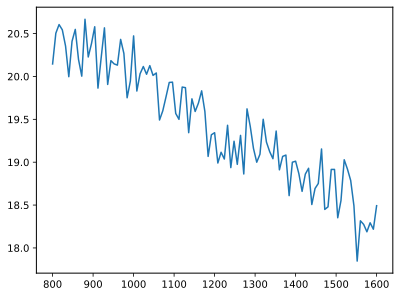

In [163]:
fig, ax = plt.subplots()
ax.plot(delay_time_dt, np.real(avg_ramsey_iq_data))